## S1-Task Vehicle Predict

### Goal 目标

API key = KGAT_53788d07f5f72126b602b031635897c1

## 1 Packages and data load (5mins) 库与数据加载

- [x] Import packages
- [x] Set directories
- [x] Load dataset
- [x] Preview data

In [61]:
# ============================================================
# 模块1：库导入与环境配置
# ============================================================
# 操作系统接口：用于路径操作、工作目录检查
import os
# 面向对象的路径处理：比os.path更简洁易用
from pathlib import Path
# 数值计算核心库：提供数组、矩阵运算及数学函数
import numpy as np
# 数据分析核心库：提供DataFrame数据结构，用于表格处理
import pandas as pd
# 基础绘图库：提供底层绘图API
import matplotlib.pyplot as plt
# 高级统计绘图库：基于matplotlib，提供更美观的统计图表
import seaborn as sns
# pandas类型检查工具：用于判断列是否为数值类型
from pandas.core.dtypes.common import is_numeric_dtype

# sklearn机器学习库组件：
# ColumnTransformer: 对不同列类型应用不同的预处理流水线
from sklearn.compose import ColumnTransformer
# SimpleImputer: 缺失值填充器（均值、中位数、众数、常数）
from sklearn.impute import SimpleImputer
# LinearRegression: 经典线性回归模型（普通最小二乘法）
from sklearn.linear_model import LinearRegression
# train_test_split: 数据集划分工具（训练集/验证集/测试集）
from sklearn.model_selection import train_test_split
# Pipeline: 将预处理和模型封装为流水线，避免数据泄露
from sklearn.pipeline import Pipeline
# OneHotEncoder: 类别特征独热编码；StandardScaler: 数值特征标准化
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 全局绘图配置：设置seaborn白色网格主题，提升图表可读性
sns.set_theme(style="whitegrid")


In [4]:
# ============================================================
# 模块2：数据路径定义
# ============================================================
# 定义数据目录（相对路径），存放车辆数据集
DATA_DIR = Path(r"vehicles")

# 拼接各数据文件的完整路径：
# - 训练集：含目标变量price，用于模型训练
# - 测试集：不含目标变量，用于生成提交结果
# - 数据描述：字段含义说明（帮助理解业务含义）
train_path = DATA_DIR / "vehicles_train.csv"
test_path = DATA_DIR / "vehicles_test.csv"
description_path = DATA_DIR / "data_description.txt"

# 路径存在性检查：确保数据文件就位，防止后续读取失败
print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())


当前目录: C:\Users\Tolia\Documents\GitHub\ITMO-MA\EnterExam\ai\Practice\S1-1\vehicles
train.csv: True
test.csv : True
description: False


In [5]:
# ============================================================
# 模块3：数据加载
# ============================================================
# NA_VALUES 可自定义额外的缺失值标记（如"NA", "None", "N/A"等）
# 此处使用pandas默认缺失值识别规则（NaN, None等）

# keep_default_na=True：保留默认缺失值识别逻辑
# 读取训练集（含特征+目标变量price）
train = pd.read_csv(train_path, keep_default_na=True)
# 读取测试集（仅特征，不含目标变量，用于最终预测）
test = pd.read_csv(test_path, keep_default_na=True)


In [6]:
# ============================================================
# 模块4：数据初步预览
# ============================================================
# 输出数据集维度（行数, 列数），判断数据规模是否符合预期
# 训练集应明显大于测试集（通常70-80% vs 20-30%）
print("train shape:", train.shape)
print("test shape :", test.shape)

# 查看前5行数据：
# 1. 确认列名是否正确加载
# 2. 快速了解各字段的取值范围和格式
# 3. 初步判断是否存在明显的数据异常
display(train.head())
display(test.head())


train shape: (376522, 23)
test shape : (50044, 22)


,listing_id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
0,veh_d420fe9aca09,gainesville,33990,2020.0,ford,ranger supercrew xl pickup,good,NaN,other,1193.0,...,NaN,NaN,pickup,NaN,Carvana is the safer way to buy a car During t...,NaN,fl,29.670000,-82.330000,2021-05-04T13:41:41-0400
1,veh_dbe8c873c362,atlanta,30690,2014.0,ram,pickup 1500,NaN,8 cylinders,gas,74500.0,...,rwd,full-size,pickup,grey,Most common questions about this vehicle: Wan...,NaN,ga,34.087409,-83.945058,2021-05-03T06:52:28-0400
2,veh_43c98563244a,danville,36590,2017.0,chevrolet,tahoe lt sport utility,good,NaN,other,60476.0,...,NaN,NaN,SUV,silver,Carvana is the safer way to buy a car During t...,NaN,va,36.580000,-79.400000,2021-04-10T09:04:50-0400
3,veh_0ec1871fa0ac,santa maria,14995,2011.0,ford,explorer base,good,6 cylinders,gas,77597.0,...,fwd,NaN,other,silver,2011*Ford*Explorer*Base -Stock 1485 The Auto S...,NaN,ca,36.683288,-121.652752,2021-05-03T10:21:23-0700
4,veh_df1e58878111,hartford,388,2002.0,mercury,sable,NaN,NaN,gas,150000.0,...,NaN,NaN,NaN,NaN,Don't get into a car payment you can't afford....,NaN,ct,41.448297,-72.828444,2021-04-25T18:15:06-0400


,listing_id,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
0,veh_821ca226bd74,nashville,2015.0,ford,f-150,excellent,NaN,gas,101366.0,clean,...,rwd,NaN,pickup,black,Call ☏ (615) 992−3147 First Class Auto Sales ...,NaN,tn,36.292259,-86.733337,2021-04-28T15:00:14-0500
1,veh_c35dafc9d02c,green bay,2001.0,pontiac,grand prix gt,excellent,6 cylinders,gas,117000.0,clean,...,fwd,NaN,coupe,brown,"2001 Pontiac Grand Prix. 117,000 miles. Brand ...",NaN,wi,44.493600,-88.079700,2021-04-30T18:08:41-0500
2,veh_82566b7397a7,asheville,2002.0,volkswagen,jetta tdi,fair,4 cylinders,diesel,225000.0,clean,...,fwd,compact,sedan,silver,"2002 VW JETTA TDI Automatic 225,000 42MPG/48MP...",NaN,nc,35.594400,-82.548500,2021-04-24T21:14:24-0400
3,veh_432de3b9b9e2,birmingham,2020.0,nissan,altima,NaN,NaN,gas,6333.0,clean,...,fwd,NaN,NaN,red,phone: ☎ (205) 862-8003 text: Text ...,NaN,al,32.922900,-86.545000,2021-04-21T08:54:53-0500
4,veh_51090c18706c,north jersey,2016.0,chevrolet,NaN,NaN,8 cylinders,other,2522.0,clean,...,fwd,compact,other,NaN,2016 *** Chevrolet Corvette 3LZ Z06*** ...,NaN,nj,44.927304,-123.030322,2021-04-28T17:33:23-0400


In [46]:
# ============================================================
# 模块5：目标变量(price)初步统计分析
# ============================================================
# 中位数：相比均值对离群值更鲁棒，反映价格的"中间水平"
# 若中位数远低于均值 → 正偏态分布（高价车拉高均值）
price_median = train['price'].median()
print(price_median)

# 偏度(Skewness)：衡量分布的不对称程度
#   skew > 0  → 正偏（右偏）：长尾在高价侧，常见于价格数据
#   skew = 0  → 对称分布（正态分布）
#   skew < 0  → 负偏（左偏）：长尾在低价侧
# 正偏时通常需对目标变量做log变换以改善模型拟合
price_skewness = train['price'].skew()
print(price_skewness)


13500.0
238.92974391405744


## 2 Data quality analysis (10 mins) 数据质量检查

- [x] Missing: missing count, missing rate
  缺失值异常：缺失数量、缺失率
- [x] Duplicated: duplicated rows, duplicated ids, duplicated entities
  重复异常：重复值、重复ID、重复实体
- [x] Outliers: distribution, extreme value
  离群异常：离群分布、极端值
- [x] Logic Inconsistent: time logic, quantity-existence, category-numeric, total-subtotal
  逻辑一致性异常：时间逻辑、数量和存在关系、类别和数值冲突、总量分量关系等
- [x] Invalidation: invalid range, invalid category, impossible value
  非法值异常：非法范围、非法类别等
- [ ] Formatting: case inconsistency, spacing, typos, empty strings, date/text format
  数据格式异常：拼写错误、大小写不一致、多余空格、空字符串等

### 2.1 Data understanding 数据理解

In [7]:
# ============================================================
# 模块6：列分类与基本信息
# ============================================================
print("--- ID/Target ---")
# ID列：唯一标识每条记录（listing_id = 车辆广告ID），不可用于建模
ID_COL = "listing_id"
# 目标列：需要预测的车辆价格
TARGET_COL = "price"

print("Target:", TARGET_COL)
print("Target dtype:", train[TARGET_COL].dtype)

print("\n--- Columns Classify ---")
# 自动分类列类型：
# NUM_COL = 数值列（int/float）→ 可用统计量描述，可直接输入模型
# OBJ_COL = 类别列（object/string）→ 需编码后才能输入模型
NUM_COL = train.select_dtypes(include=[np.number]).columns
OBJ_COL = train.select_dtypes(exclude=[np.number]).columns
print("Numerical Columns:", NUM_COL.tolist())
print("\nObjective Columns:", OBJ_COL.tolist())

# 输出完整数据概览：列名、非空计数、数据类型、内存占用
# 帮助快速识别：
# 1. 哪些列有大量缺失
# 2. 数据类型是否合理（如year应为int，不应是object）
print("\n--- train.info() ---")
print(train.info())


--- ID/Target ---
Target: price
Target dtype: int64

--- Columns Classify ---
Numerical Columns: ['price', 'year', 'odometer', 'county', 'lat', 'long']

Objective Columns: ['listing_id', 'region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'description', 'state', 'posting_date']

--- train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376522 entries, 0 to 376521
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   listing_id    376522 non-null  object 
 1   region        376522 non-null  object 
 2   price         376522 non-null  int64  
 3   year          375317 non-null  float64
 4   manufacturer  360770 non-null  object 
 5   model         371738 non-null  object 
 6   condition     221300 non-null  object 
 7   cylinders     220083 non-null  object 
 8   fuel          373785 non-null  object 
 9   odo

### 2.2 Missing value check 缺失值检查

- [x] missing count
- [x] missing rate

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

| Missing rate | Handle strategy            |
|--------------|----------------------------|
| <0.1%        | 可以考虑直接删除对应行                |
| 0.1% ~ 5%    | 优先考虑简单填充                   |
| 5% ~ 30%     | 根据特征语义选择填充策略               |
| >30%         | 重点判断 NA 是否具有业务含义，不能仅凭缺失率决定 |

In [8]:
# ============================================================
# 模块7：缺失值检查函数
# ============================================================
# 参数说明：
#   df: 待分析DataFrame
#   columns: 指定列（None=全部列）
#   missing_only: 是否仅显示有缺失的列
#   sort_by: 排序列（missing_count缺失数 / missing_rate缺失率）
#   ascending: 升序/降序
def missing_report(
        df: pd.DataFrame,
        columns=None,
        missing_only=True,
        sort_by="missing_rate",
        ascending=False):

    # 若指定列则子集筛选
    if columns is not None:
        df = df[columns]

    # 生成缺失值报告表：
    #   dtype: 列数据类型
    #   missing_count: 缺失值个数（isna().sum()）
    #   missing_rate: 缺失值比例（isna().mean()）
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean()
    })

    # 过滤无缺失的列（仅保留有缺失问题的特征）
    if missing_only:
        report = report[report["missing_count"] > 0]

    # 按指定规则排序后返回
    return report.sort_values(by=sort_by, ascending=ascending)

# 临时设置显示选项：显示所有行/列，避免报告被截断
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(missing_report(train))


,dtype,missing_count,missing_rate
county,float64,376522,1.000000
size,object,269947,0.716949
cylinders,object,156439,0.415484
condition,object,155222,0.412252
VIN,object,142515,0.378504
paint_color,object,115528,0.306829
drive,object,115089,0.305663
type,object,82220,0.218367
manufacturer,object,15752,0.041836
title_status,object,7471,0.019842


### 2.3 Duplication check 重复值检查

- [x] 总重复行检查
- [x] ID 重复行检查
- [x] ID 部分缺失下的重复检查

In [9]:
# ============================================================
# 模块8：重复值检查
# ============================================================
# 总重复行：所有列完全相同的行（可能是数据加载/写入错误）
print("Total duplicated rows:", train.duplicated().sum())

# ID重复检查：同一listing_id出现多次（可能是数据追加错误）
# keep=False：标记所有重复项（包括第一次出现）
print("Duplicated rows num by Id:", train[ID_COL].duplicated(keep=False).sum())
print("Unique Id num:", train[ID_COL].nunique())
print("Total rows num:", len(train))

# 提取所有重复的ID，查看具体重复记录
# （用于判断是完全重复还是同一ID不同数据的冲突）
dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


Total duplicated rows: 0
Duplicated rows num by Id: 0
Unique Id num: 376522
Total rows num: 376522


,listing_id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date


In [10]:
# ============================================================
# 模块9：实体级重复检查（非ID维度）
# ============================================================
# 思路：ID可能重复/缺失，但真实世界中"同一辆车"应有唯一的属性组合
# （如：manufacturer+model+year+odometer+VIN等组合应唯一）

# 自定义排除列：ID和目标变量不参与"唯一实体"判定
IDENTIFY_COLS_EXCLUDE = [
    ID_COL,
    TARGET_COL,
]
# 其余所有列共同组成唯一实体判定键
IDENTIFY_COLS = train.drop(columns=IDENTIFY_COLS_EXCLUDE).columns.tolist()

# 实体重复报告函数
def duplicated_entities_report(
        df: pd.DataFrame,
        identify_columns=None):

    # 按指定列组判定重复（keep=False标记全部重复项）
    duplicated_mask = df.duplicated(subset=identify_columns, keep=False)

    # 提取重复的实体行
    duplicated_df = df.loc[duplicated_mask, identify_columns]
    # 按实体分组，统计每组重复次数
    duplicated_groups = (
        duplicated_df.groupby(identify_columns, dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("Duplicated entities:", len(duplicated_df))
    print("Duplicated groups:", len(duplicated_groups))

    # 返回所有重复实体的原始行（按首列排序便于人工核对）
    return df[duplicated_mask][identify_columns].sort_values(identify_columns[0])

display(duplicated_entities_report(train, IDENTIFY_COLS))


Duplicated entities: 57
Duplicated groups: 18


,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
53714,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
180388,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
187033,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
59067,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
114385,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
243443,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
260433,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
149967,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
325307,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
16126,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN


### 2.4 Outliers check 离群值检查

- Numeric outlier
  - outlier count
  - outlier rate
- Categoric outlier
  - unique count
  - top frequency

In [42]:
# ============================================================
# 模块10：数值变量统计描述
# ============================================================
# describe()生成8项统计量：
#   count: 非空值个数
#   mean: 均值（易受离群值影响）
#   std: 标准差（数据离散程度）
#   min: 最小值（检查是否异常，如价格<0、年份为负）
#   25%: 下四分位数Q1
#   50%: 中位数
#   75%: 上四分位数Q3
#   max: 最大值（检查是否异常，如odometer过亿）
print("--- 数值变量统计 ---")
display(train.describe())


--- 数值变量统计 ---


,price,year,odometer,county,lat,long
count,3.765220e+05,375317.000000,3.721340e+05,0.0,370431.000000,370431.000000
mean,8.269784e+04,2011.093915,9.870859e+04,NaN,38.489771,-94.856771
std,1.297137e+07,9.829812,2.266628e+05,NaN,5.842851,18.405112
min,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,5.500000e+03,2008.000000,3.751800e+04,NaN,34.586025,-112.024820
50%,1.350000e+04,2013.000000,8.523400e+04,NaN,39.140621,-88.607000
75%,2.599500e+04,2017.000000,1.331220e+05,NaN,42.410000,-80.873548
max,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [13]:
# ============================================================
# 模块11：离群值检查函数（基于IQR方法）
# ============================================================
# IQR（四分位距）= Q3 - Q1
# 正常值范围：[Q1 - k*IQR, Q3 + k*IQR]，k通常取1.5（中度）或3.0（极端）
# 优点：无需假设分布；对非正态分布数据鲁棒
def outlier_report(
        df: pd.DataFrame,
        cols,
        multiplier=1.5,
        sort_by="outlier_rate",):

    outliers = []
    for col in cols:
        # 跳过非数值列
        if not is_numeric_dtype(df[col]):
            continue

        # 去除缺失值后计算（缺失值不参与离群判定）
        data = df[col].dropna()
        if len(data) == 0:
            continue

        # 计算四分位数
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        # 四分位距
        IQR = Q3 - Q1

        # 正常值上下界
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        # 统计离群值数量和比例
        outlier_count = ((data < lower) | (data > upper)).sum()
        outlier_rate = outlier_count / len(data)

        outliers.append({
            "column": col,
            "count": len(data),
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower": lower,
            "upper": upper,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate
        })

    # 转为DataFrame并按离群率降序排列
    report = pd.DataFrame(outliers).set_index("column")
    report.index.name = None

    # 仅保留有离群值的列
    report = report[report["outlier_count"] > 0]

    return report.sort_values(by=sort_by, ascending=False)

# 转置显示：让列名在上方，指标在左侧，便于横向对比各特征
display(outlier_report(train, cols=train.columns).T)


,year,price,lat,odometer,long
count,375317.000000,376522.000000,370431.000000,372134.000000,370431.000000
Q1,2008.000000,5500.000000,34.586025,37518.000000,-112.024820
Q3,2017.000000,25995.000000,42.410000,133122.000000,-80.873548
IQR,9.000000,20495.000000,7.823975,95604.000000,31.151272
lower,1994.500000,-25242.500000,22.850063,-105888.000000,-158.751727
upper,2030.500000,56737.500000,54.145962,276528.000000,-34.146641
outlier_count,15426.000000,7566.000000,5613.000000,4078.000000,178.000000
outlier_rate,0.041101,0.020094,0.015153,0.010958,0.000481


In [15]:
# ============================================================
# 模块12：类别变量统计描述
# ============================================================
# describe(exclude=[np.number])输出：
#   count: 非空值个数
#   unique: 不同取值的个数（基数cardinality）
#   top: 出现次数最多的类别（众数）
#   freq: 众数出现次数
# 高基数特征（如state有50+取值）需考虑频率编码或合并稀有类别
print("--- 类别变量统计 ---")
display(train.describe(exclude=[np.number]).T)


--- 类别变量统计 ---


,count,unique,top,freq
listing_id,376522,376522,veh_9afecb9748c4,1
region,376522,404,columbus,3116
manufacturer,360770,42,ford,62470
model,371738,27678,f-150,7028
condition,221300,6,good,105499
cylinders,220083,8,6 cylinders,82955
fuel,373785,5,gas,314148
title_status,369051,6,clean,357143
transmission,374183,3,automatic,297624
VIN,234007,104686,1FMJU1JT1HEA52352,261


### 2.5 Logic Inconsistency/Invalid Value 逻辑不一致/非法值

- Date/time logic
- Quantity-existence
- Category-numeric
- Total-subtotal

In [16]:
# ============================================================
# 模块13：业务规则/逻辑一致性检查
# ============================================================
# RULES格式：[("规则描述", 布尔条件Series)]
# 示例规则：
#   ("年份不应超过当前年", train["year"] > 2026)
#   ("里程数不应为负", train["odometer"] < 0)
#   ("价格与车况矛盾", (train["condition"]=="excellent") & (train["price"] < 1000))
# 当前RULES为空，需根据业务知识补充
RULES = [

]

def check_rule(df, rule, n_samples=5):
    name, condition = rule
    # 筛选违反规则的行
    violations = df[condition]

    print(name, len(violations))

    # 若有违规，抽样展示供人工核查
    if len(violations) > 0:
        display(violations.head(n_samples))

    return violations

# 遍历检查所有规则
for RULE in RULES:
    check_rule(train, RULE, len(train))


### 2.6 Format Issues

- dtype
- String Format
- Date/Time
- Spacing
- Encoding

In [ ]:
# ============================================================
# 模块14：类别特征取值穷举
# ============================================================
# 遍历所有类别列，输出：
#   1. 列名
#   2. 唯一值数量（基数）
#   3. 全部唯一取值列表
# 目的：
#   - 发现拼写不一致（如"Ford"/"ford"/"FORD"）
#   - 发现同义词（如"Automatic"/"Auto"）
#   - 发现异常类别值（空字符串、明显错误的输入）
for col in OBJ_COL:
    print(col, train[col].nunique(), train[col].unique())


### 2-Task B1

Нормализуйте VIN в vehicles_train.csv: исключите пропуски (NaN/NA), у остальных значений удалите пробелы по краям и приведите их к верхнему регистру; строки, ставшие пустыми после удаления пробелов, также исключите. Формат и длину VIN не валидируйте, а остальные непустые строки (например, NONE) дополнительно не интерпретируйте как пропуски. Сколько уникальных нормализованных VIN встречаются в train 2 и более раз, и сколько «лишних» объявлений они порождают (сумма повторов сверх первого)? Формат: уникальных_VIN; лишних_объявлений.  

对 vehicles_train.csv 中的车辆识别码 (VIN) 进行规范化：移除空白值 (NaN/NA)，移除剩余值末尾的空格并将其转换为大写；同时排除移除空格后变为空的行。不验证 VIN 的格式和长度，也不将其他非空行（例如 NONE）视为空白。有多少个唯一的规范化 VIN 在数据集中出现两次或两次以上？它们会生成多少条“额外”广告（除第一次重复外的重复次数之和）？格式：unique_VINs; extra_ads。

In [21]:
# ============================================================
# 模块15：任务B1 - VIN码规范化与重复广告统计
# ============================================================
# 题目要求：
#   1. 排除VIN为NaN/NA的记录
#   2. 去除字符串两端空格
#   3. 转换为大写
#   4. 排除去空格后变为空字符串的记录
#   5. 统计：重复VIN的数量 + 重复广告总次数（出现≥2次的VIN，超出1次的部分之和）

VALID_DATA_1 = train['VIN']

# Step 1: 丢弃NaN值（dropna()）
vin_clean = VALID_DATA_1.dropna()

# Step 2: 强制转为字符串类型（防止非字符串导致后续str方法报错）
vin_clean = vin_clean.astype(str)

# Step 3: rstrip()仅去除右侧空格；upper()转为大写
# 若需去除两侧空格应使用strip()，此处按题目要求仅去右端
vin_clean = vin_clean.str.rstrip().str.upper()

# Step 4: 过滤清洗后变为空串的记录
vin_clean = vin_clean[vin_clean != ""]

# Step 5: 统计每个VIN出现的次数
vin_counts = vin_clean.value_counts()

# 出现≥2次的VIN的数量 = 有重复的"不同VIN"的个数
unique_VINs = (vin_counts >= 2).sum()
# 额外广告数 = Σ(每个重复VIN的出现次数 - 1)
# 如VIN-A出现3次 → 贡献2条额外广告；VIN-B出现2次 → 贡献1条
extra_ads = (vin_counts[vin_counts >= 2] - 1).sum()

# 输出格式要求：用"; "分隔两个答案
print(f"{unique_VINs}; {extra_ads}")


35652; 129321


### 2-Task B2

Возьмите подвыборку 2000 ≤ year ≤ 2020, 500 ≤ price ≤ 100000 и определите возраст машины как age = 2021 − year. Для каждого из топ-5 производителей по числу объявлений (в этой подвыборке) оцените наклон линейной регрессии log10(price) ~ age. У какого производителя цена падает с возрастом авто круче всего (минимальный наклон)? Ответ: производитель, как записан в данных.  

选取子样本 2000 ≤ year ≤ 2020，500 ≤ price ≤ 100000，并计算车辆年龄为 age = 2021 − year。对于此子样本中排名前五的制造商，分别估计 log10(price) ~ age 线性回归的斜率。哪个制造商的车辆价格随车龄下降幅度最大（斜率最小）？答案：制造商，数据记录如此。

In [28]:
# ============================================================
# 模块16：任务B2 - Top5制造商车辆贬值率对比分析
# ============================================================
# 筛选有效数据子集：
#   year在2000-2020之间（排除过老/未上市的车）
#   price在500-100000之间（排除测试数据/录入错误）
VALID_DATA_2 = train[
    (train["year"] >= 2000) &
    (train["year"] <= 2020) &
    (train["price"] >= 500) &
    (train["price"] <= 100000)
].copy()

# 构造衍生特征：
#   age: 车龄 = 2021 - 生产年份（假定数据采集于2021年）
#   log_price: 价格对数变换（log10），让价格分布更接近正态，线性回归效果更好
VALID_DATA_2["age"] = 2021 - VALID_DATA_2["year"]
VALID_DATA_2["log_price"] = np.log10(VALID_DATA_2["price"])

# 取广告数量最多的前5个制造商（样本量充足，统计结论可靠）
top5 = (VALID_DATA_2["manufacturer"].value_counts().head(5))

print("Top 5 manufacturers:")
print(top5)

# 对每个制造商分别拟合一元线性回归：log_price ~ age
# 斜率(slope/coef)含义：车龄每增加1年，log10(价格)平均减少多少
# 斜率的绝对值越大 → 贬值越快（越不保值）
slopes = {}

for manufacturer in top5.index:
    # 子集筛选：仅当前品牌
    df = VALID_DATA_2[
        VALID_DATA_2["manufacturer"] == manufacturer
    ]

    X = df[["age"]]        # 特征：车龄（二维输入，sklearn要求）
    y = df["log_price"]    # 目标：log10价格

    reg = LinearRegression()
    reg.fit(X, y)          # 拟合普通最小二乘回归

    # coef_[0]获取唯一自变量的回归系数（斜率）
    slopes[manufacturer] = reg.coef_[0]

# 输出各品牌贬值斜率（应为负数，越大越接近0表示越保值）
print("\nSlopes:")
for k, v in slopes.items():
    print(k, v)

# 答案：取斜率最小者（即最小值，贬值最快的品牌）
# 注意：如果想找"最保值"的品牌，应取max（最接近0的负数）
answer = min(
    slopes,
    key=slopes.get
)

print("\nAnswer:", answer)


manufacturer
ford         50661
chevrolet    38295
toyota       25572
honda        16381
nissan       14547
Name: count, dtype: int64

Top 5 manufacturers:
manufacturer
ford         50661
chevrolet    38295
toyota       25572
honda        16381
nissan       14547
Name: count, dtype: int64

Slopes:
ford -0.0459162807894753
chevrolet -0.04407559964914778
toyota -0.04705353845003537
honda -0.05227698385251538
nissan -0.04993156759418579

Answer: honda


### 2-Task B3

Среди штатов с не менее чем 5000 объявлений в train — в каком штате самая высокая медианная цена пикапов (type == "pickup", 500 ≤ price ≤ 100000)? Ответ: двухбуквенный код штата, как в данных.  

在至少有 5,000 条车辆信息录入数据库的州中，哪个州的皮卡车价格中位数最高（type == "pickup", 500 ≤ price ≤ 100,000）？答案：两位字母的州代码，数据记录如此。

In [33]:
# ============================================================
# 模块17：任务B3 - 各州皮卡(pickup)价格中位数对比
# ============================================================
# Step 1: 按州统计广告数量，筛选样本量≥5000的州
# 原因：样本太少的州中位数波动大，统计结论不可靠
state_counts = train['state'].value_counts()
valid_stats_index = state_counts[state_counts >= 5000].index
display(valid_stats_index)

# Step 2: 筛选有效样本
#   - 州在样本充足列表中
#   - 车辆类型为pickup（皮卡/货卡，美国市场热门车型）
#   - 价格范围正常（500-100000）
VALID_DATA3 = train[
    (train["state"].isin(valid_stats_index)) &
    (train["type"] == "pickup") &
    (train["price"] >= 500) &
    (train["price"] <= 100000)
].copy()

# Step 3: 按州分组，计算各组price的中位数
# 使用中位数而非均值：价格分布正偏，中位数更能代表"典型价格"
median_prices = (
    VALID_DATA3
    .groupby("state")["price"]
    .median()
    .sort_values(ascending=False)
)

display(median_prices.head())

# Step 4: 取中位数最高的州作为答案
# idxmax()返回最大值对应的索引（即州名缩写，如CA, TX等）
answer = median_prices.idxmax()

print("Answer:", answer)


Index(['ca', 'fl', 'tx', 'ny', 'oh', 'or', 'mi', 'nc', 'wa', 'pa', 'wi', 'co',
       'tn', 'va', 'il', 'nj', 'id', 'az', 'ia', 'ma', 'mn', 'ga', 'ok', 'mt',
       'sc', 'ks', 'in'],
      dtype='object', name='state')

state
az    33991.0
tx    31681.0
wa    30999.0
sc    30990.0
in    30590.0
Name: price, dtype: float64

state
az    33991.0
tx    31681.0
wa    30999.0
sc    30990.0
in    30590.0
Name: price, dtype: float64

Answer: az


### 2-Task B4

Сколько объявлений содержат слово salvage в description (без учёта регистра), но при этом имеют title_status == "clean"? Целое число. Одним предложением: что это говорит о качестве поля title_status?

有多少条车辆信息在描述中包含“salvage”（不区分大小写）一词，但 title_status == "clean"？整数。用一句话概括：这说明了 title_status 字段的质量如何？

In [34]:
# ============================================================
# 模块18：任务B4 - 矛盾信息检测（版本1）
# ============================================================
# 检测目标：description描述中提到"salvage"（全损车/残值车），
#           但title_status却标记为"clean"（正常产权）的矛盾记录数
# 业务背景：salvage车通常应有salvage title，两者矛盾暗示数据可能有误或卖家隐瞒
mask = (
    # 描述列：先填充NaN为空串，再做不区分大小写的关键词匹配
    train["description"]
    .fillna("")
    .str.contains(
        "salvage",
        case=False
    )
) & (
    # 产权状态严格等于"clean"
    train["title_status"] == "clean"
)

count = mask.sum()
print(count)


2200


In [35]:
# ============================================================
# 模块19：任务B4 - 矛盾信息检测（版本2，链式写法）
# ============================================================
# 与版本1逻辑完全等价，仅写法不同：
# 将两个条件直接串联在一个布尔表达式中，减少中间变量
count = (
    train["description"]
    .fillna("")
    .str.contains("salvage", case=False)
    &
    (train["title_status"] == "clean")
).sum()

print(count)


2200


### 2-Task B5. Аномалия

Опишите одну аномалию или проблему качества данных, которую вы нашли (кроме упомянутых в вопросах выше), и сформулируйте гипотезу о её причине. Свободный ответ, 2–5 предложений. Подтверждающую визуализацию включите в ноутбук, который загрузите в финальном разделе «Файлы решения»; отдельная ссылка здесь не нужна.

描述一个你发现的异常情况或数据质量问题（除上述问题中提到的问题外），并提出一个关于其原因的假设。自由回答，2-5 句话。请在笔记本中包含相关的可视化图表，并在最终的“解决方案文件”部分上传；无需提供单独的链接。

Price的skewness非常大，数据严重右偏，并且使用describe分析发现Price存在少量非常大的极端值，有可能是错误数据或者是

### 2-C1 Regression result submit

C1. Модель цены на отложенной выборке C1. 价格模型（带留出法） 

Постройте модель предсказания price по `vehicles_train.csv` и сделайте предсказания для всех строк `vehicles_test.csv`. Фиксированный протокол для обучения: используйте train-строки с `500 ≤ price ≤ 100000`, `year ≥ 1990`, `odometer ≤ 500000`; базовые табличные признаки — `year, odometer, manufacturer, condition, cylinders, fuel, title_status, transmission, drive, type, paint_color, state`; таргет — `log10(price)`. Модель — любая. Приложите CSV-файл с колонками `listing_id, price` в том же формате, что `sample_submission.csv`. Формат ответа C1: текстовый ответ не требуется. Загрузите `submission.csv` в поле сразу под условием.  

使用 `vehicles_train.csv` 构建价格预测模型，并对 `vehicles_test.csv` 中的所有行进行预测。训练规则如下：使用满足以下条件的训练行：`500 ≤ price ≤ 100000`，`year ≥ 1990`，`odometer ≤ 500000`；基本表特征包括：`year, odometer, manufacturer, condition, cylinders, fuel, title_status, transmission, drive, type, paint_color, state`；目标函数为 `log10(price)`。模型可以是任意的。请附上一个 CSV 文件，其中包含 `listing_id` 和 `price` 列，格式与 `sample_submission.csv` 相同。响应格式 C1：无需文本响应。请在条件下方的字段中上传 `submission.csv`。

In [ ]:
# ============================================================
# 模块20：主建模流程 - 车辆价格预测（线性回归基线模型）
# ============================================================

# ---------- Step 1: 训练集数据清洗（样本过滤） ----------
# 排除明显异常样本，提升模型训练质量：
#   price: 500-100000（排除测试/录入错误）
#   year: ≥1990（过老车辆规律不同，单独处理）
#   odometer: ≤500000（约80万公里，超过可能为测试车或错误数据）
train_data = train[
    (train["price"] >= 500) &
    (train["price"] <= 100000) &
    (train["year"] >= 1990) &
    (train["odometer"] <= 500000)
].copy()

# ---------- Step 2: 特征工程（选择输入模型的特征） ----------
# 选择12个业务相关特征：
#   数值型：year(年份), odometer(里程)
#   类别型：manufacturer(品牌), condition(车况), cylinders(气缸数),
#           fuel(燃油类型), title_status(产权), transmission(变速箱),
#           drive(驱动方式), type(车型), paint_color(颜色), state(州)
FEATURES = [
    "year",
    "odometer",
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state"
]

# 构造特征矩阵X（输入）和目标向量y（输出）
X = train_data[FEATURES]
# 对目标变量price做log10变换：
#   1. 将正偏态转为近似正态，改善线性回归的假设条件
#   2. 让高价车和低价车的预测误差在百分比层面更公平
y = np.log10(train_data[TARGET_COL])

# ---------- Step 3: 划分训练集/验证集 ----------
# 80%训练（模型学习），20%验证（调参评估）
# random_state=42固定随机种子，保证每次运行划分结果一致（可复现）
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------- Step 4: 特征类型拆分（用于差异化预处理） ----------
NUM_FEATURES = (X_train.select_dtypes(include="number").columns.tolist())
CAT_FEATURES = (X_train.select_dtypes(exclude="number").columns.tolist())

print(NUM_FEATURES)
print(CAT_FEATURES)

# ---------- Step 5: 构建预处理流水线 ----------
# 数值特征处理：
#   SimpleImputer(strategy="median") → 用中位数填充缺失（对离群值鲁棒）
#   注：此处未加StandardScaler，因后续使用线性回归（无正则）时缩放非必须
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))]
)

# 类别特征处理：
#   1. 缺失值填充为"Unknown"（保留"缺失"本身的信息，而非丢弃样本）
#   2. OneHotEncoder独热编码 → 将类别转为0/1哑变量，线性模型可处理
#      handle_unknown="ignore"：测试集出现训练集没有的类别时全部置0（不报错）
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

# ColumnTransformer：按列名分别应用数值/类别预处理，结果自动拼接
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUM_FEATURES),
    ("cat", categorical_transformer, CAT_FEATURES)]
)

# ---------- Step 6: 构建完整模型流水线并训练 ----------
# Pipeline将"预处理+建模"封装为统一对象：
#   - 自动避免数据泄露（验证集不会参与fit）
#   - 便于后续GridSearchCV调参
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())]
)

# 在训练集上拟合模型（自动完成预处理+训练）
model.fit(X_train, y_train)

# ---------- Step 7: 生成测试集预测 ----------
# 从测试集中提取相同的特征列（顺序必须一致）
X_test = test[FEATURES]

# 预测log10价格
pred_log = model.predict(X_test)
# 反变换回原始价格尺度：price = 10^(log10_price)
pred_price = 10 ** pred_log

# 后处理：将预测值裁剪到合理区间[500, 100000]
# 防止极端离群预测影响得分（如模型误给出price=1的结果）
pred_price = np.clip(pred_price, 500, 100000)

# ---------- Step 8: 生成提交文件 ----------
# 格式要求：两列(listing_id, price)，与sample_submission.csv完全一致
submission = pd.DataFrame({
    "listing_id": test["listing_id"],
    "price": pred_price
})

# 保存为CSV（index=False不保存行索引，避免额外列）
submission.to_csv("submission.csv", index=False)

submission.head()


In [ ]:
# ============================================================
# 模块21：提交文件验证
# ============================================================
# 确认当前工作目录（submission.csv将被保存到此处）
print(os.getcwd())

# 验证submission.csv是否成功生成（防止后续上传空文件）
print(os.path.exists("submission.csv"))


### 2-Task C2

C2. Validation и важные признаки Опишите вашу локальную validation-схему для модели из C1: как вы делили train, какие метрики считали и как избегали утечки в preprocessing. Укажите локальную MAE в долларах после обратного преобразования из log10(price), а также топ-3 признака по важности с указанием способа оценки важности.

请描述您针对 C1 中模型的本地验证方案：如何划分训练集、计算了哪些指标以及如何避免预处理中的数据泄漏。请提供以美元为单位的本地平均绝对误差 (MAE)（基于 log10(price) 进行逆变换），以及按重要性排序的前三个特征，并说明重要性评估方法。

## 3 EDA/Statistical Analysis (15mins) 探索性数据统计分析

- [x] Target analysis
- [x] Numeric analysis
- [x] Categoric analysis
- [x] Correlative analysis

Considering the large amount of data, `train_sample` will be used for analysis to speed up the process.

### 3.1 Target Analysis

- skewness 偏度
  - left skew <0: Power Transform, revert-Log Transform
  - right skew >0: Log Transform

In [ ]:
# ============================================================
# 模块22：清洗后数据的目标变量统计
# ============================================================
# 在完成样本过滤后，重新检查目标变量：
# 中位数用于判断是否需要特殊值处理（如预测值默认填充中位数）
price_median = train_data['price'].median()
print(price_median)

# 偏度用于判断log变换效果：
# 若偏度仍较高，可考虑log2/ln、平方根变换或Box-Cox变换
price_skewness = train_data['price'].skew()
print(price_skewness)


15990.0
1.2107251190233954


Target Columns: price
Target skewness: 1.2107251190233954


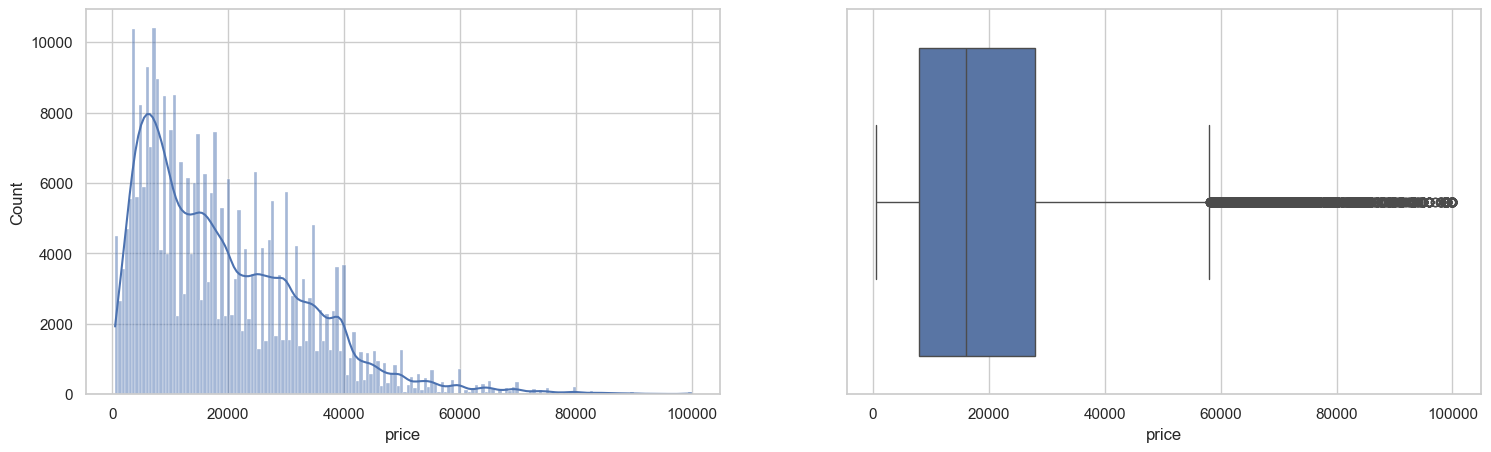

Log10 Target Columns: price
Log10 Target skewness: -0.7509429779566406


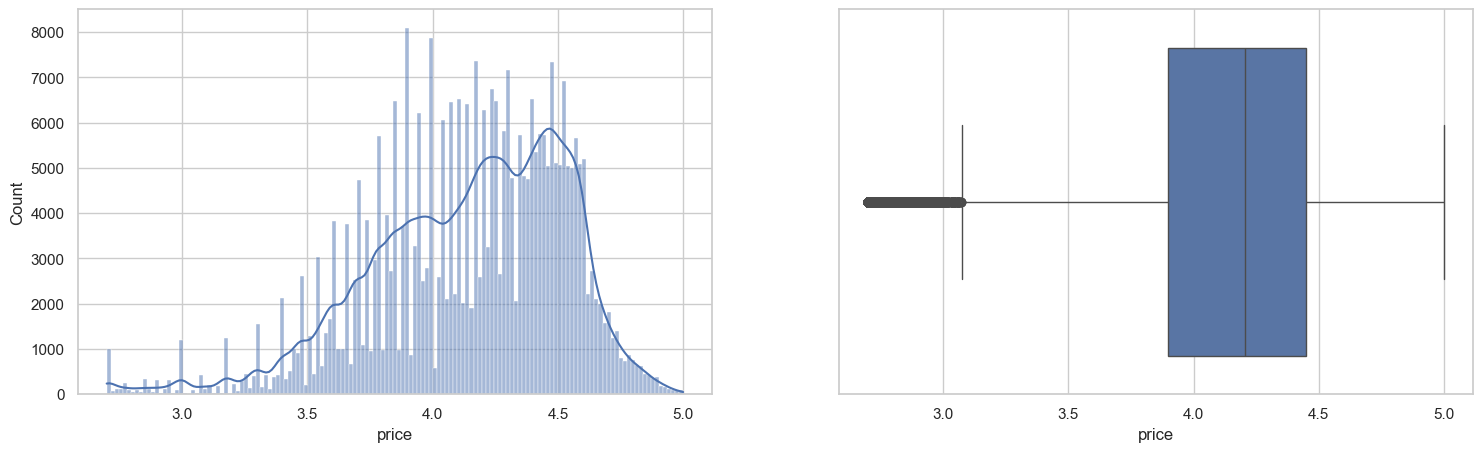

In [56]:
# ============================================================
# 模块23：目标变量分布可视化
# ============================================================
# 创建1行2列子图：左=直方图+KDE，右=箱线图
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Target Columns:", TARGET_COL)
print("Target skewness:", train_data[TARGET_COL].skew())

# 原始price分布（正偏态，长尾在高价侧）
sns.histplot(train_data[TARGET_COL], kde=True, ax=axes[0])
sns.boxplot(x=train_data[TARGET_COL], ax=axes[1])

plt.show()

# log10变换后的分布（应更接近正态对称分布）
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Log10 Target Columns:", TARGET_COL)
print("Log10 Target skewness:", Y_train.skew())

sns.histplot(Y_train, kde=True, ax=axes[0])
sns.boxplot(x=Y_train, ax=axes[1])

plt.show()


### 3.2 Numeric analysis

- Distribution

price


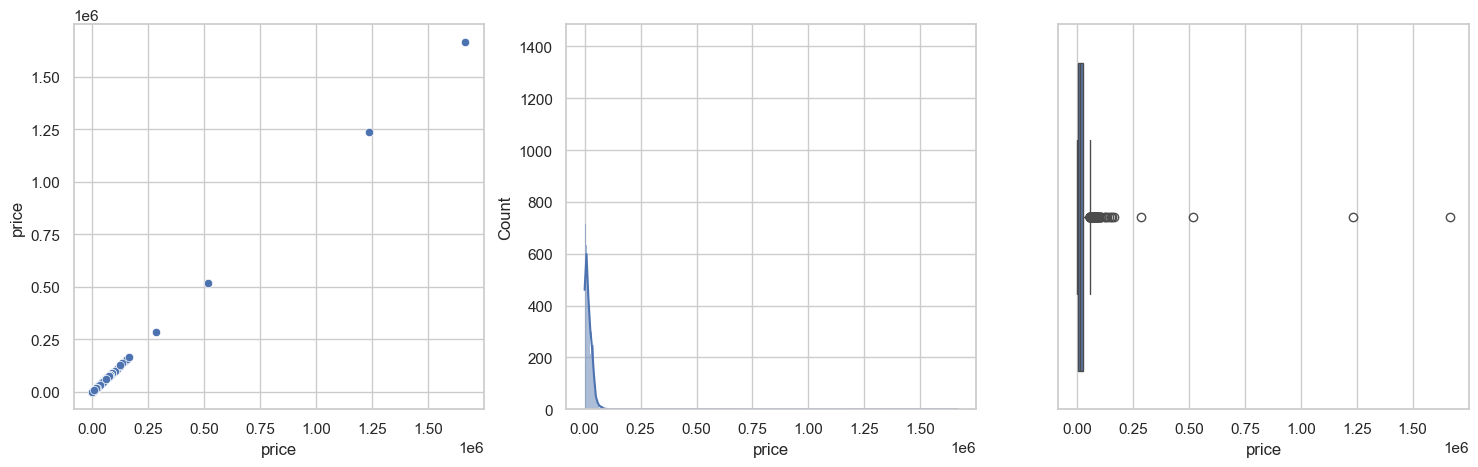

In [41]:
# ============================================================
# 模块24：数值特征与目标变量的可视化分析函数
# ============================================================
# 注意：此处NUM_FEATURES被重置为['price']，可能是调试遗留代码
# 正常应传入X_train中的真实数值特征（如year, odometer等）
NUM_FEATURES = ['price']

def visual_analyse_numeric_feature(
        df: pd.DataFrame,
        num_features,
        target,
        rotation=0):

    for feature in num_features:
        # 为每个数值特征生成3张图：
        #   ax[0] 散点图：x=特征值 vs y=目标值 → 观察线性/非线性关系
        #   ax[1] 直方图+KDE：观察特征自身分布形态
        #   ax[2] 箱线图：观察特征的离群值（IQR法）
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature], y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], ax=axes[2])

        # 可选：分箱后再观察与目标的关系（当前注释掉）
        # 用于发现U型、阈值型等非线性规律
        # subfig = plt.figure(figsize=(18, 5))
        # sns.boxplot(x=pd.cut(train[feature], bins=50, precision=1), y=train[TARGET_COL])
        # plt.xticks(rotation=90)
        # plt.show()

        # 坐标刻度旋转（应对长标签重叠）
        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()
        plt.show()

# 调用可视化（注意此处传入X_train+TARGET_COL，但X_train中不含TARGET，会报错）
# 实际应用中应传入合并后的完整DataFrame（包含特征+目标）
visual_analyse_numeric_feature(X_train, NUM_FEATURES, TARGET_COL, rotation=0)


### 3.3 Categoric Analysis

- Distribution

In [ ]:
# ============================================================
# 模块25：类别特征与目标变量的可视化分析函数
# ============================================================
# CAT_FEATURES为空列表，当前未启用类别特征可视化
# 可取消下一行注释以启用所有类别列的分析
CAT_FEATURES = []
# CAT_FEATURES = OBJ_COL

def visual_analyse_categoric_feature(
        df: pd.DataFrame,
        cat_features,
        target,
        rotation=0):
    for feature in cat_features:
        # 为每个类别特征生成3张图：
        #   ax[0] 散点图：类别 vs 目标（点重叠严重，信息量低）
        #   ax[1] 直方图：各类别样本量分布（发现稀有/高频类别）
        #   ax[2] 箱线图：各类别下目标变量的分布（核心！看类别区分力）
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature], y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], y=df[target], ax=axes[2])

        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()

# 当前CAT_FEATURES为空，不会生成任何图表
visual_analyse_categoric_feature(train, CAT_FEATURES, TARGET_COL)


### Correlative Analysis
- pearson
- spearman

## 4 Train/Valid Split(5 min)

## 5 Feature Engineering (15 min) 特征工程

- Feature Selection
  - by correlation
  - by importance
- Feature Creation
- Feature Combination
  - Total/Sum/Count
- Feature Transformation
  - Log Transformation
  - Polynomial Transformation
  - Binning
- Feature Extraction
  - Date/Time Feature: Festival, Used time
  - Text Feature: description → vector(TF-IDF/embeddings)
  - Image Feature: pixel/color/shape


## 6 Preprocess (15 mins) 预处理

- Missing value handle: Numeric, Categoric
- Outlier handle: delete, replace, transform
- Feature Encoding
  - One-Hot Encoding
  - Ordinal Encoding
- Feature Scaling
  - Standardization: mean → 0, std → 1
  - Normalization: value → [0~1]

### 6.1 Missing Value Handle
No missing value, no need to handle

### 6.2 Duplicated Value Handle
No global duplicated entity, no need to handle

### 6.3 Outlier Handle
Basically normal, no need to handle

### 6.4 Logic Consistency Handle

No logic consistency, no need to handle

### 6.5 Categoric Encode
- One-Hot Encoding: for nominal categorical feature

### 6.6 Target Skew

### 6.6 Pipeline

## 7 Model Training (30 mins) 模型训练

- Baseline model Select
  - Regression: LinealRegression, GradientBoost
- Model Training
- Valid Predict

## 8 Evaluation (10 mins) 评估指标

## 9 Conclution

